<a href="https://colab.research.google.com/github/dauhoangganh/ADXL382_Pico_Streamlit_Example/blob/main/CNN_LSTM_stepping_motor_fault_classification_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Jul  7 02:37:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             52W /  400W |     709MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# **Dataset acquisition**

In [1]:
# remove dataset folder
!rm -rf /content/dataset
# prompt: unzip dateset.zip in content folder
!unzip /content/dataset.zip -d /content/
%cd /content/dataset
%ls /content/dataset

Archive:  /content/dataset.zip
   creating: /content/dataset/
   creating: /content/dataset/Bubble/
  inflating: /content/dataset/Bubble/data (1).csv  
  inflating: /content/dataset/Bubble/data (10).csv  
  inflating: /content/dataset/Bubble/data (100).csv  
  inflating: /content/dataset/Bubble/data (101).csv  
  inflating: /content/dataset/Bubble/data (102).csv  
  inflating: /content/dataset/Bubble/data (103).csv  
  inflating: /content/dataset/Bubble/data (104).csv  
  inflating: /content/dataset/Bubble/data (105).csv  
  inflating: /content/dataset/Bubble/data (106).csv  
  inflating: /content/dataset/Bubble/data (107).csv  
  inflating: /content/dataset/Bubble/data (108).csv  
  inflating: /content/dataset/Bubble/data (109).csv  
  inflating: /content/dataset/Bubble/data (11).csv  
  inflating: /content/dataset/Bubble/data (110).csv  
  inflating: /content/dataset/Bubble/data (111).csv  
  inflating: /content/dataset/Bubble/data (112).csv  
  inflating: /content/dataset/Bubble/dat

In [11]:
"""
Any config specific to data acquisition step goes here.
"""

from pathlib import Path
import glob
from collections import namedtuple

# Select input data directory
INPUT_DATA_DIR = Path('/content/dataset/')
# Input data paths
MEDIUM_RATE_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Medium_rate/*.csv')
SLOW_RATE_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Slow_rate/*.csv')
FAST_RATE_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Fast_rate/*.csv')
STOP_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Stop/*.csv')
STALL_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Stall/*.csv')
UNBALANCED_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Unbalance/*.csv')
OCCLUSION_FILE_NAMES = glob.glob(str(INPUT_DATA_DIR)+'/Occlusion/*.csv')
# Output data path
OUTPUT_DATA_DIR = Path('/content/drive/MyDrive/checkpoints')
OUTPUT_DATA_FILE = OUTPUT_DATA_DIR / Path('raw_data.p')

# Dataset = namedtuple(
#     'Dataset',
#     'medium_rate slow_rate fast_rate stop stall unbalanced occlusion'
#     )
Dataset = namedtuple(
    'Dataset',
    'medium_rate slow_rate fast_rate stop stall unbalanced occlusion'
    )

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import logging
import pickle

logging.basicConfig(level=print)


def _dataReader(path_names: list) -> list:
    '''
    Reads in raw data from .csv files and returns a list

    params:
    ---
    path_names (list): list of all the data files to read in

    returns:
    ---
    sequences (list): raw dataset from data directory
    '''

    sequences = list()

    for name in path_names:
        data = pd.read_csv(name, header=0)
        sequences.append(data.values)

    return sequences #shape (n_samples, n_time_points, n_channels)


def get_save_data() -> Dataset:
    '''
    runs the `_dataReader` method and
    stores the raw data into a Dataset named tuple.

    returns:
    ---
    dataset (Dataset): named tuple of (data_n)
    '''
    if Path.exists(OUTPUT_DATA_FILE):
        print('Loading previously pickled `raw_data`')
        dataset = pickle.load(open(OUTPUT_DATA_FILE, 'rb'))
    else:
        OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

        print("Loading raw data.")

        data_medium_rate = np.stack(_dataReader(MEDIUM_RATE_FILE_NAMES)) #shape (n_samples, n_time_points, n_channels)
        data_slow_rate = np.stack(_dataReader(SLOW_RATE_FILE_NAMES))
        data_fast_rate = np.stack(_dataReader(FAST_RATE_FILE_NAMES))
        data_stop = np.stack(_dataReader(STOP_FILE_NAMES))
        data_stall = np.stack(_dataReader(STALL_FILE_NAMES))
        data_unbalanced = np.stack(_dataReader(UNBALANCED_FILE_NAMES))
        data_occlusion = np.stack(_dataReader(OCCLUSION_FILE_NAMES))
        print("Load complete.")

        dataset = Dataset(
            data_medium_rate,
            data_slow_rate,
            data_fast_rate,
            data_stop,
            data_stall,
            data_unbalanced,
            data_occlusion
            )

        pickle.dump(dataset, open(OUTPUT_DATA_FILE, 'wb'))

    return dataset

In [13]:
a = _dataReader(STALL_FILE_NAMES)
for i in range(len(a)):
  print(STALL_FILE_NAMES[i])
  print(a[i].shape)

/content/dataset/Stall/data (52).csv
(24000, 3)
/content/dataset/Stall/data (13).csv
(24000, 3)
/content/dataset/Stall/data (73).csv
(24000, 3)
/content/dataset/Stall/data (23).csv
(24000, 3)
/content/dataset/Stall/data (9).csv
(24000, 3)
/content/dataset/Stall/data (14).csv
(24000, 3)
/content/dataset/Stall/data (50).csv
(24000, 3)
/content/dataset/Stall/data (49).csv
(24000, 3)
/content/dataset/Stall/data (56).csv
(24000, 3)
/content/dataset/Stall/data (46).csv
(24000, 3)
/content/dataset/Stall/data (24).csv
(24000, 3)
/content/dataset/Stall/data (26).csv
(24000, 3)
/content/dataset/Stall/data (27).csv
(24000, 3)
/content/dataset/Stall/data (44).csv
(24000, 3)
/content/dataset/Stall/data (35).csv
(24000, 3)
/content/dataset/Stall/data (68).csv
(24000, 3)
/content/dataset/Stall/data (41).csv
(24000, 3)
/content/dataset/Stall/data (4).csv
(24000, 3)
/content/dataset/Stall/data (29).csv
(24000, 3)
/content/dataset/Stall/data (67).csv
(24000, 3)
/content/dataset/Stall/data (11).csv
(2400

In [14]:
dataset = get_save_data()
print(len(dataset.medium_rate))
print(len(dataset.slow_rate))
print(len(dataset.fast_rate))
print(len(dataset.stop))
print(len(dataset.stall))
print(len(dataset.unbalanced))
print(len(dataset.occlusion))

Loading raw data.
Load complete.
98
104
102
61
76
89
75


# **Data processing**

In [15]:
"""
Any config specific to data processing step goes here.
"""

DATA_TEST_SIZE = 0.1  # Test sample size
SAMPLE_RATE = 16000  # Data acquisition system processing frequency
RESAMPLE_RATE = 1  # Resample rate used to desample the time-series
DURATION = 1.5  # Time-series duration in seconds

# Output data path
OUTPUT_TRAIN_TEST_DATA_DIR = Path('/content/drive/MyDrive/checkpoints')
OUTPUT_TRAIN_TEST_DATA_FILE = OUTPUT_DATA_DIR / Path('train_test_data.p')
# Graph Output data path
GRAPH_OUTPUT_DATA_DIR = Path('/content/drive/MyDrive/output/plots')

ProcessedDataset = namedtuple('ProcessedDataset', 'X_train X_test y_train y_test')

In [16]:

"""
Any utility function that is required for data processing goes here
"""

from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.fft import rfft
import logging
import pickle

logging.basicConfig(level=print)

def apply_wiener_filter(data, mysize=31):
    """
    Apply Wiener filter to 3D time-series data (samples, time steps, features).

    Parameters:
        data (np.ndarray): Input shape (n_samples, n_steps, n_features)
        mysize (int): Size of Wiener filter window

    Returns:
        np.ndarray: Denoised data with same shape
    """
    denoised = np.empty_like(data)

    for i in range(data.shape[0]):           # loop over samples
        for j in range(data.shape[2]):       # loop over features (e.g., x/y/z)
            denoised[i, :, j] = scipy.signal.wiener(data[i, :, j], mysize=mysize, noise=1e-8)


    return denoised

def get_scaler(X_train):
    X_train_2d = X_train.reshape(-1, X_train.shape[2])#reshapes 3D array into a 2D array where all the time steps from all samples are stacked together while still having 3 feature columns.
    scaler = StandardScaler() #learn the mean and std of train_data per feature, across all frequency bins
    scaler.fit(X_train_2d)
    return scaler

def _dataScaler(data: list, scaler) -> list:
    '''
    Reads in data and returns a scaled list.

    params:
    ---
    data (list): a list of data to scale--->(3D array (samples, time steps, features))

    returns:
    ---
    final_sequence (list): resampled data
    '''


    # Reshape for scaling
    data_2d = data.reshape(-1, data.shape[2])#reshapes 3D array into a 2D array where all the time steps from all samples are stacked together while still having 3 feature columns.
    data_scaled = scaler.transform(data_2d)
    data_scaled = data_scaled.reshape(data.shape)
    return data_scaled


def _downSampler(data: list, start_index: int, sample_rate: int) -> list:
    '''
    Reads in raw data from .csv files and returns a resampled list

    params:
    ---
    data (list): a list of data to down sample --->(3D array (samples, time steps, features))
    start_index (int): starting index
    sample_rate (int): sampling rate

    returns:
    ---
    final_sequence (list): resampled data
    '''
    final_sequence = list()
    for dataset in data:
        data_resampled = []
        start = start_index
        stop = sample_rate
        for i in range(int(len(dataset)/sample_rate)):
            data_resampled.append(dataset[start:stop, :].mean(axis=0))
            start += sample_rate
            stop += sample_rate
        final_sequence.append(np.stack(data_resampled))

    return np.stack(final_sequence)


def _FFT(data: list) -> list:
    '''
    Reads in resampled data and performs a Fast Fourier Transform with DC offset removal

    params:
    ---
    data (pd.DataFrame): a list of data to perform Fast Fourier Transform --->(3D array (samples, time steps, features))
    returns:
    ---
    data_fft (list): FFT data
    '''
    data_fft = list()
    for dataset in data:
      #rfft(dataset, axis=0): This is the core of the FFT operation. rfft stands for "real FFT," which is an optimized version of the FFT for real-valued input data (like the time-series data in this case).
      #It computes the one-dimensional discrete Fourier Transform along the specified axis (axis=0, which is the time step axis). The output of rfft is complex-valued and contains the frequency components of the signal.
      #np.abs(...): This takes the absolute value of the complex output from rfft. The absolute value of a complex number gives its magnitude, which represents the strength or amplitude of the corresponding frequency component in the signal.
      # [1:, :]: This is array slicing. In the context of the FFT output, the first element (index 0) typically represents the DC component (the average value or zero frequency component) of the signal. This slicing effectively removes the DC component from the FFT result.
        data_fft.append(np.stack(np.abs(rfft(dataset, axis=0))[1:, :]))

    return np.stack(data_fft)


In [17]:
"""
Any utility function that is required for data exploratory analysis goes here
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfftfreq

def time_plot(yf_list, start: int, stop: int, fname: str, legend: list):
    '''
    Plots a time series

    params:
    ---
    yf_list (list of np.ndarray): input data to plot
    start (int): start time (s)
    stop (int): stop time (s)
    fname (str): save file name
    legend (list): legend names
    '''
    time = np.linspace(0, DURATION, len(yf_list[0]), endpoint=False)

    _, axs = plt.subplots(nrows=1, figsize=(11, 9))
    plt.rcParams['font.size'] = '14'

    for label in (axs.get_xticklabels() + axs.get_yticklabels()):
        label.set_fontsize(14)
    for yf in yf_list:
      plt.plot(time[start:stop], yf[start:stop], label=legend.pop(0))

    axs.set_title('Time-series signal')
    axs.set_ylabel('Acceleration (g)', fontsize=14)
    axs.set_xlabel('Time (s)', fontsize=14)
    axs.legend()
    GRAPH_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    file_location = GRAPH_OUTPUT_DATA_DIR / Path(f'{fname}.png')
    plt.savefig(file_location)


def fft_plot(yf_list, fname: str, legend: list):
    '''
    Plots the FFT

    params:
    ---
    yf_list (list of np.ndarray): input data to plot
    fname (str): save file name
    '''
    # N = int((SAMPLE_RATE / RESAMPLE_RATE) * DURATION) #N=16000/1*2 = 32000
    N = max([yf_list[i].shape[0]*2 for i in range(len(yf_list))])
    xf = rfftfreq(N-1, 1 / int(SAMPLE_RATE / RESAMPLE_RATE)) #resulting spectrum has N//2 + 1 frequency bins

    _, axs = plt.subplots(nrows=1, figsize=(11, 9))
    plt.rcParams['font.size'] = '14'

    for label in (axs.get_xticklabels() + axs.get_yticklabels()):
        label.set_fontsize(14)

    for i, yf in enumerate(yf_list):
        plt.plot(xf, yf, label=legend[i])
    axs.set_title('Frequency spectra')
    axs.set_ylabel('Signal strength', fontsize=14)
    axs.set_xlabel('Frequency (Hz)', fontsize=14)
    axs.legend()
    GRAPH_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
    file_location = GRAPH_OUTPUT_DATA_DIR / Path(f'{fname}.png')
    plt.savefig(file_location)

In [ ]:
# Data Plotting
data_medium_rate = dataset.medium_rate.copy()
# data_stop = dataset.stop.copy()
data_slow_rate = dataset.slow_rate.copy()
data_fast_rate = dataset.fast_rate.copy()
# data_stall = dataset.stall.copy()

In [ ]:
data_medium_rate[0][:, [1]]

array([[0.   ],
       [0.   ],
       [0.   ],
       ...,
       [0.133],
       [0.135],
       [0.138]])

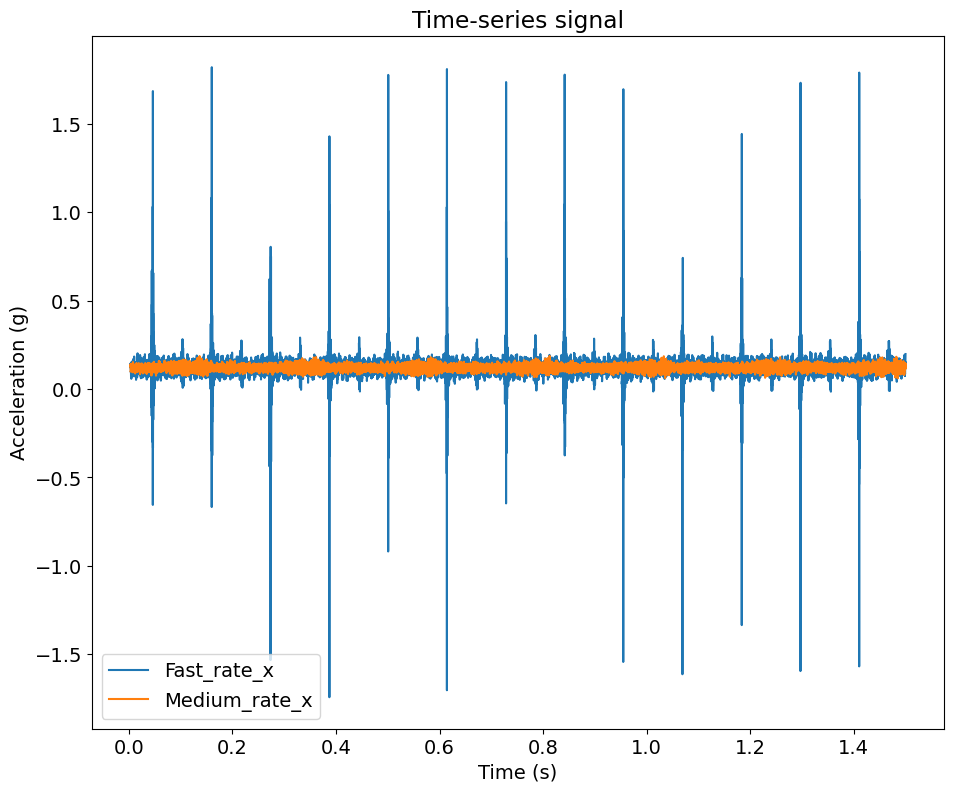

In [ ]:
time_plot([ data_fast_rate[50][:, [1]], data_medium_rate[50][:, [1]]], 50, SAMPLE_RATE*DURATION, 'time_plot', legend=["Fast_rate_x", "Medium_rate_x"])

In [ ]:
# time_plot([data_medium_rate[0][:, [1]], data_stop[0][:, [1]], data_slow_rate[0][:, [1]]], 50, int(SAMPLE_RATE*DURATION), 'time_plot', legend=["Medium_rate_y", "Stop_y", "Slow rate_y"])

In [ ]:
# time_plot([data_medium_rate[0][:, [2]], data_stop[0][:, [2]], data_slow_rate[0][:, [2]]], 50, int(SAMPLE_RATE*DURATION), 'time_plot', legend=["Medium_rate_z", "Stop_z", "Slow rate_z"])

In [ ]:
# # Data Resampling
# data_n_resampled = _downSampler(data_medium_rate[:, 50:, :], 0, RESAMPLE_RATE)
# data_n_resampled_fft = _FFT(data_n_resampled)
# data_n_resampled_fft.shape

In [ ]:
# data_stop_resampled = _downSampler(data_stop[:, 50:, :], 0, RESAMPLE_RATE)
# data_stop_resampled_fft = _FFT(data_stop_resampled)

# data_fast_rate_resampled = _downSampler(data_fast_rate[:, 50:, :], 0, RESAMPLE_RATE)
# data_fast_rate_resampled_fft = _FFT(data_fast_rate_resampled)

# data_slow_rate_resampled = _downSampler(data_slow_rate[:, 50:, :], 0, RESAMPLE_RATE)
# data_slow_rate_resampled_fft = _FFT(data_slow_rate_resampled)

# data_stall_resampled = _downSampler(data_stall[:, 50:, :], 0, RESAMPLE_RATE)
# data_stall_resampled_fft = _FFT(data_stall_resampled)

In [ ]:
# fft_plot([ data_stall_resampled_fft[10][:, [0]], data_n_resampled_fft[15][:, [0]]], 'fft__resampled', legend=["Stall_x", "Medium_rate_x" ])

In [ ]:
# fft_plot([data_n_resampled_fft[25][:, [1]], data_stall_resampled_fft[60][:, [1]]], 'fft__resampled', legend=["Medium_rate_y", "Stall_y"])

In [ ]:
# fft_plot([data_n_resampled_fft[2][:, [2]], data_stall_resampled_fft[64][:, [2]]], 'fft__resampled', legend=["Medium_rate_z", "Stall_z"])

In [ ]:
# fft_plot([data_n_resampled_fft[0][:, [2]], data_fast_rate_resampled_fft[0][:, [2]], data_slow_rate_resampled_fft[0][:, [2]]], 'fft_medium_rate_resampled', legend=["Medium_rate_z", "Fast rate_z", "Slow rate_z"])

In [ ]:
# Data Scaling

# time_plot([data_stop_resampled[0][:, [0]], data_stop_resampled[0][:, [1]], data_stop_resampled[0][:, [2]]], 0, SAMPLE_RATE*DURATION, 'data_scaled', legend=["x", "y", "z"])


# **Model training**

In [25]:
"""
Any config specific to model training step goes here.
"""

from pathlib import Path
import scipy.signal

# General configuration
MONITOR = 'val_loss'
VAL_SPLIT = 0.1
# LSTM_UNITS = 200
OPTIMIZER = 'adam'
EPOCHS = 300

# Multi-class classification
OUTPUT_SIZE = 7 #7 labels for classification
ACTIVATION = 'softmax'
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

# Output data path
OUTPUT_MODEL_DIR = Path('/content/drive/MyDrive/output')

# Scaler file path
OUTPUT_SCALER_FILE = OUTPUT_MODEL_DIR / Path('scaler.pkl')

In [21]:
def get_save_train_test_data(raw_data: Dataset, n_noise_points = 50) -> ProcessedDataset:
    '''
    runs the 'get_data()' and '_downSampler' methods
    to generate training and testing data sets

    params:
    ---
    dataset (Dataset): raw data set from data_acquisition module
    n_noise_points : number of data points to remove at the beginning of the dataset due to ringing

    returns:
    ---
    train_test_data (Dataset): named tuple of (X_train, y_train, X_test, y_test)
    '''
    if Path.exists(OUTPUT_TRAIN_TEST_DATA_FILE) and Path.exists(OUTPUT_SCALER_FILE):
        print('Loading previously pickled `train_test_data`')
        train_test_data = pickle.load(open(OUTPUT_TRAIN_TEST_DATA_FILE, 'rb'))
        print('Loading previously pickled `scaler`')
        scaler = pickle.load(open(OUTPUT_SCALER_FILE, 'rb'))
    else:
        OUTPUT_TRAIN_TEST_DATA_DIR.mkdir(parents=True, exist_ok=True)

        print(f"Data is being resampled at a sample rate of: {RESAMPLE_RATE}")
        data_medium_rate = _downSampler(raw_data.medium_rate[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_slow_rate = _downSampler(raw_data.slow_rate[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_fast_rate = _downSampler(raw_data.fast_rate[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_stop = _downSampler(raw_data.stop[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_stall = _downSampler(raw_data.stall[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_unbalanced = _downSampler(raw_data.unbalanced[:, n_noise_points:, :], 0, RESAMPLE_RATE)
        data_occlusion = _downSampler(raw_data.occlusion[:, n_noise_points:, :], 0, RESAMPLE_RATE)

        print("Removing noise") # Wiener filtering
        data_medium_rate = apply_wiener_filter(data_medium_rate)
        data_slow_rate = apply_wiener_filter(data_slow_rate)
        data_fast_rate = apply_wiener_filter(data_fast_rate)
        data_stop = apply_wiener_filter(data_stop)
        data_stall = apply_wiener_filter(data_stall)
        data_unbalanced = apply_wiener_filter(data_unbalanced)
        data_occlusion = apply_wiener_filter(data_occlusion)

        print("Creating labels.")
        y_1 = np.zeros(int(len(data_medium_rate)), dtype=int)
        y_2 = np.full(int(len(data_slow_rate)), 1)
        y_3 = np.full(int(len(data_fast_rate)), 2)
        y_4 = np.full(int(len(data_stop)), 3)
        y_5 = np.full(int(len(data_stall)), 4)
        y_6 = np.full(int(len(data_unbalanced)), 5)
        y_7 = np.full(int(len(data_occlusion)), 6)

        y = np.concatenate((y_1, y_2, y_3, y_4, y_5, y_6, y_7))

        X = np.concatenate((data_medium_rate, data_slow_rate, data_fast_rate, data_stop, data_stall, data_unbalanced, data_occlusion))

        print(f"Spliting data to a test size of: {DATA_TEST_SIZE}")

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=DATA_TEST_SIZE, random_state=42, shuffle=True) #shuffle and split data for training and testing
        print("Scaling the data.")
        scaler = get_scaler(X_train)

        # Scale train and test data
        X_train = _dataScaler(X_train, scaler)

        X_test = _dataScaler(X_test, scaler)


        train_test_data = ProcessedDataset(X_train, X_test, y_train, y_test)
        pickle.dump(train_test_data, open(OUTPUT_TRAIN_TEST_DATA_FILE, 'wb'))
        pickle.dump(scaler, open(OUTPUT_SCALER_FILE, 'wb'))
        print("Complete.")

    return train_test_data, scaler

In [22]:
import joblib
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, LSTM, Input, Multiply
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# logging.basicConfig(level=print)

OUTPUT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Model Development
# Load the data
# dataset = get_save_data()

# Process the data and train/test split
train_test_data, scaler  = get_save_train_test_data(dataset)


# Prepare the data
X_train = np.array(train_test_data.X_train)
X_test = np.array(train_test_data.X_test)

y_train = np.array(train_test_data.y_train)
y_test = np.array(train_test_data.y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

Data is being resampled at a sample rate of: 1
Removing noise
Creating labels.
Spliting data to a test size of: 0.1
Scaling the data.
Complete.


((544, 23950, 3), (61, 23950, 3), (544,), (61,))

In [ ]:
np.min(X_train)

np.float64(-55.977047211621375)

In [26]:
# Generating the model

def build_dual_encoder_model(input_shape=(250, 3), num_classes=5):
    # Input
    input_layer = Input(shape=input_shape)

    # First encoder path
    encoder1 = Conv1D(filters=50, kernel_size=20, strides=2, padding='same', activation='relu')(input_layer)
    encoder1 = Conv1D(filters=30, kernel_size=10, strides=2, padding='same', activation='relu')(encoder1)
    encoder1 = MaxPooling1D(pool_size=2, padding='same',)(encoder1)

    # Second encoder path
    encoder2 = Conv1D(filters=50, kernel_size=6, strides=1, padding='same', activation='relu')(input_layer)
    encoder2 = Conv1D(filters=40, kernel_size=6, strides=1, padding='same', activation='relu')(encoder2)
    encoder2 = MaxPooling1D(pool_size=2, padding='same',)(encoder2)
    encoder2 = Conv1D(filters=30, kernel_size=6, strides=1, padding='same', activation='relu')(encoder2)
    encoder2 = Conv1D(filters=30, kernel_size=6, strides=2, padding='same', activation='relu')(encoder2)
    encoder2 = MaxPooling1D(pool_size=2, padding='same',)(encoder2)

    # Merge the encoders
    merged = Multiply()([encoder1, encoder2])

    # LSTM layers
    lstm = LSTM(units=60, return_sequences=True)(merged)
    lstm = LSTM(units=60)(lstm)
    dropout = Dropout(rate=0.5)(lstm)

    # Output
    output = Dense(num_classes, activation='softmax')(dropout)

    # Define the model
    model = Model(inputs=input_layer, outputs=output)
    return model

model = build_dual_encoder_model(input_shape=[X_train.shape[1], X_train.shape[2]], num_classes=OUTPUT_SIZE)
print(model.summary())
model_path = OUTPUT_MODEL_DIR / Path('best_model.keras')
chk = ModelCheckpoint(model_path, monitor=MONITOR, save_best_only=True, mode='auto', verbose=1)
early_stopping_cb = EarlyStopping(monitor=MONITOR, patience=10, restore_best_weights=True)
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 23950, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 23950, 50) │        950 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 23950, 40) │     12,040 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 11975, 40) │          0 │ conv1d_9[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 11975, 50) │      3,050 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 11975, 30) │      7,230 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 5988, 30)  │     15,030 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 5988, 30)  │      5,430 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 2994, 30)  │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 2994, 30)  │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 2994, 30)  │          0 │ max_pooling1d_3[… │
│ (Multiply)          │                   │            │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 2994, 60)  │     21,840 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 60)        │     29,040 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │        427 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 95,037 (371.24 KB)

 Trainable params: 95,037 (371.24 KB)

 Non-trainable params: 0 (0.00 B)

None


# **Model training**

In [27]:
# Training the model

hist = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=[chk, early_stopping_cb],
    validation_split=VAL_SPLIT
    )



Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.2205 - loss: 1.8625
Epoch 1: val_loss improved from inf to 1.62939, saving model to /content/drive/MyDrive/output/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 300ms/step - accuracy: 0.2228 - loss: 1.8597 - val_accuracy: 0.4364 - val_loss: 1.6294
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.4822 - loss: 1.5484
Epoch 2: val_loss improved from 1.62939 to 1.33729, saving model to /content/drive/MyDrive/output/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 268ms/step - accuracy: 0.4806 - loss: 1.5466 - val_accuracy: 0.4727 - val_loss: 1.3373
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5567 - loss: 1.2696
Epoch 3: val_loss improved from 1.33729 to 1.06313, saving model to /content/drive/MyDrive/output/best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step - accuracy: 0.5553 - loss: 1.2697 - val_accuracy: 0.5636 - val_loss: 1.0631
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms

# **Model validation**

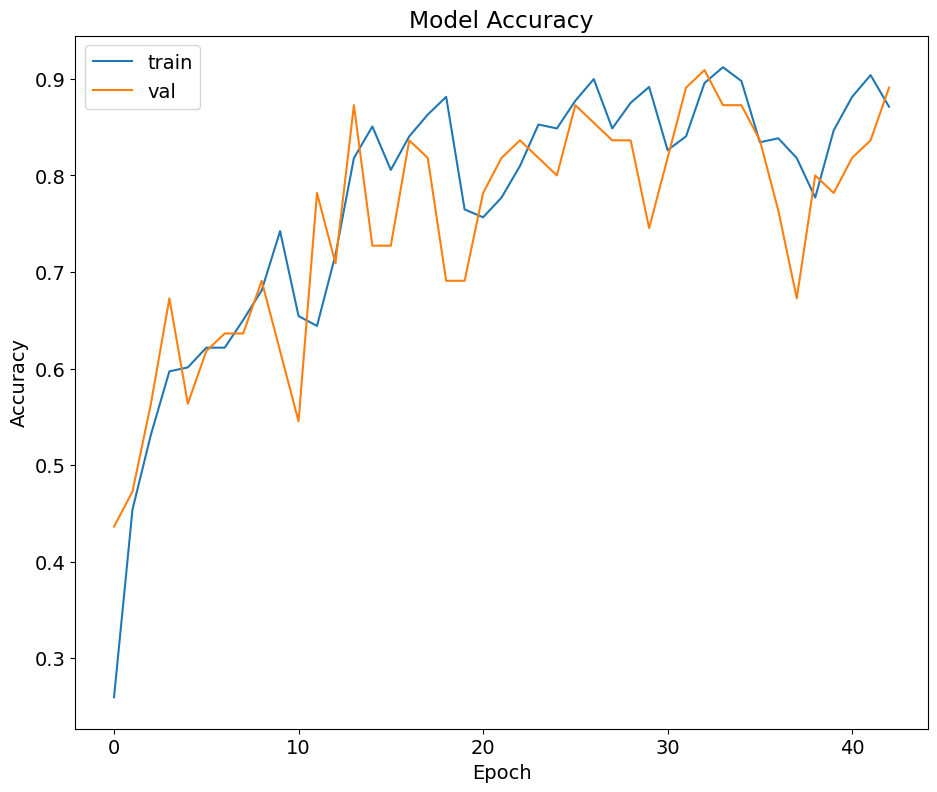

In [28]:
# Model Validation
# Plotting training and validation accuracy per epoch
_, axs = plt.subplots(nrows=1, figsize=(11, 9))
file_location = OUTPUT_MODEL_DIR / Path('plots/model_accuracy.png')
plt.rcParams['font.size'] = '14'

for label in (axs.get_xticklabels() + axs.get_yticklabels()):
    label.set_fontsize(14)

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])

axs.set_title('Model Accuracy')
axs.set_ylabel('Accuracy', fontsize=14)
axs.set_xlabel('Epoch', fontsize=14)
plt.legend(['train', 'val'], loc='upper left')
# plt.savefig(file_location)

# **Model evaluation**

In [29]:
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model
# Prepare the data
# X_test = np.array(train_test_data.X_test)
# y_test = np.array(train_test_data.y_test)

# Loading the model and checking accuracy on the test data
model_path = OUTPUT_MODEL_DIR / Path('best_model.keras')
model = load_model(model_path)

#model.predict(X_test) produces the predicted probabilities for each class for every sample in X_test.
#Output shape: (num_samples, num_classes) (e.g., (100, 4) for 4 classes).
#np.argmax(..., axis=-1) picks the index (class) with the highest predicted probability for each sample.
test_preds = np.argmax(model.predict(X_test), axis=-1)
print(accuracy_score(y_test, test_preds))



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
0.9508196721311475


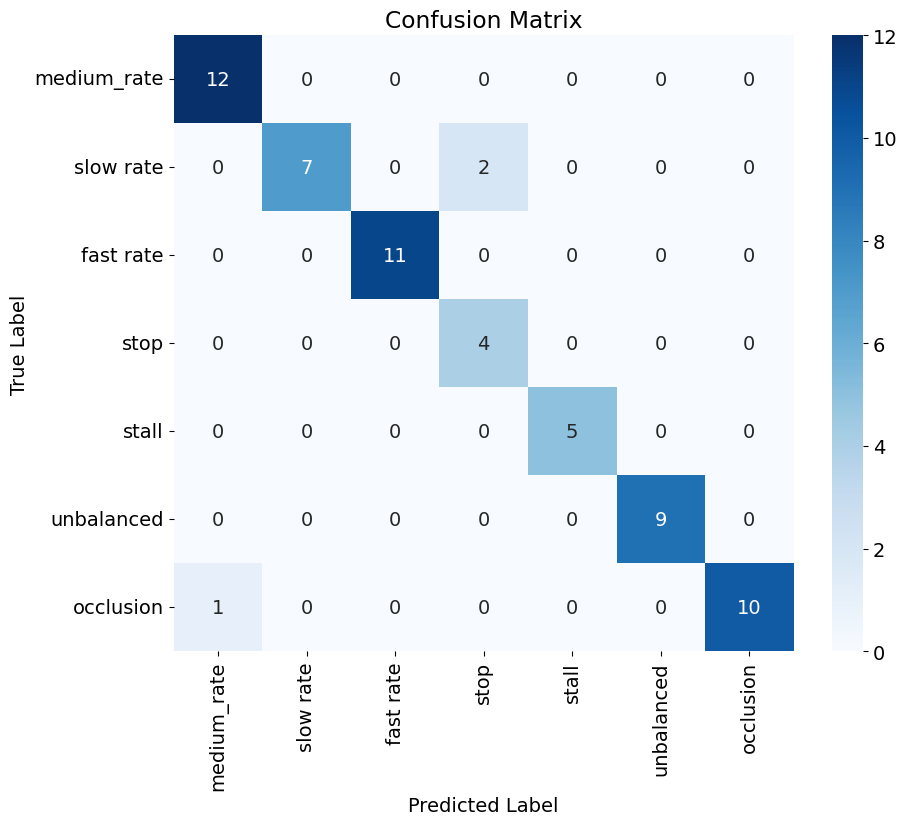

In [31]:
# prompt: create confusion matrix for my evaluation result

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create the confusion matrix
conf_matrix = confusion_matrix(y_test, test_preds)


# # Comparing the actual values versus the predicted values
data_dict = {
    0: 'medium_rate',
    1: 'slow rate',
    2: 'fast rate',
    3: 'stop',
    4: 'stall',
    5: 'unbalanced',
    6: 'occlusion'
    }
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=data_dict.values(), yticklabels=data_dict.values())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# **Deploy the trained model**

In [ ]:
import pandas as pd
import joblib


sensor_data = pd.read_csv('/content/unbalance_2.csv', header=0).values
sensor_data

array([[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
       [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
       [ 5.0000e-04,  5.0000e-04, -1.5000e-03],
       ...,
       [-2.1900e-01,  1.0650e-01,  1.0575e+00],
       [-2.2150e-01,  1.2350e-01,  1.0670e+00],
       [-2.4550e-01,  1.3650e-01,  1.0575e+00]])

In [ ]:
sensor_data.shape

(24000, 3)

In [ ]:
import numpy as np
sensor_data = np.expand_dims(sensor_data, axis=0)
sensor_data.shape

(1, 24000, 3)

In [ ]:
# Data Resampling
sensor_data_resampled = _downSampler(sensor_data[:, 50:, : ], 0, RESAMPLE_RATE)

#Noise removal
sensor_data= apply_wiener_filter(sensor_data_resampled)

#Scaling data
scaler = joblib.load(OUTPUT_SCALER_FILE)
sensor_data = _dataScaler(sensor_data, scaler)
sensor_data.shape


(1, 23950, 3)

<Figure size 1200x600 with 0 Axes>

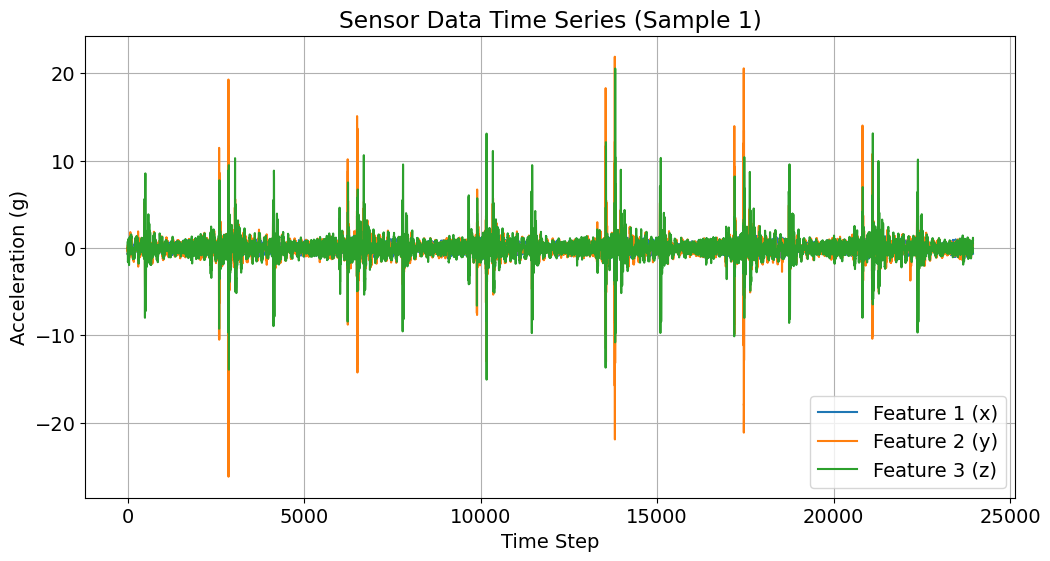

In [ ]:
# prompt: plot sensor_data

import matplotlib.pyplot as plt
# Assuming sensor_data is a 3D numpy array (samples, time steps, features)
# Plot the first sample and the first feature (e.g., x-axis acceleration)
plt.figure(figsize=(12, 6))

# If you want to plot all features for the first sample:
plt.figure(figsize=(12, 6))
plt.plot(sensor_data[0, :, 0], label='Feature 1 (x)')
plt.plot(sensor_data[0, :, 1], label='Feature 2 (y)')
plt.plot(sensor_data[0, :, 2], label='Feature 3 (z)')
plt.title('Sensor Data Time Series (Sample 1)')
plt.xlabel('Time Step')
plt.ylabel('Acceleration (g)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
sensor_data.shape

(1, 23950, 3)

In [ ]:
predictions = model.predict(sensor_data)
print(f"Predictions: {predictions}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predictions: [[0.03858022 0.01387102 0.566916   0.35352826 0.02710448]]


In [ ]:
#there is only one sample in fft_data so get the first prediction
predicted_classes = np.argmax(predictions, axis=1)[0]
pred_confidence = np.max(predictions, axis=-1)[0]

In [ ]:
print('Predicted class: ', predicted_classes)
print('Confidence: ', pred_confidence)

Predicted class:  2
Confidence:  0.566916
